<a href="https://colab.research.google.com/github/Amirtha-Raja-Rajeswari/PPA_Lab/blob/main/PPA_LAB_EXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EXP 1 - Clustering based data analysis uisng python**

  Preparing metadata (setup.py) ... done
  Created wheel for Minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=74179f7b50ffb74f6de019b1dc401123663d7c7736e7c98cabec44c8bc418cb7
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built Minisom


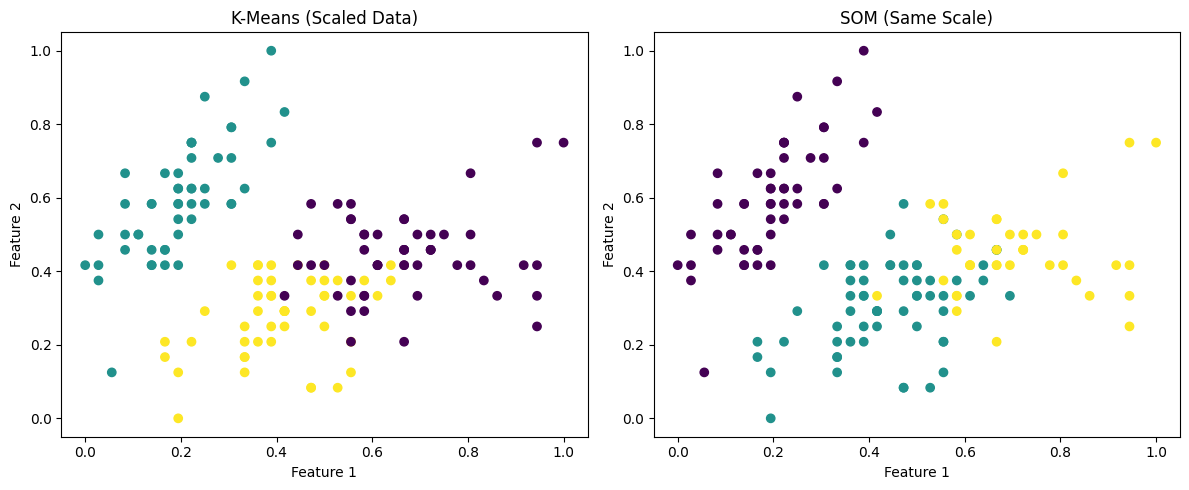

In [ ]:
!pip install Minisom
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

iris = load_iris()
X = iris.data
y = iris.target

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

som = MiniSom(x=3, y=1, input_len=4, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 500)

som_labels = []
for x in X_scaled:
    winner = som.winner(x)
    som_labels.append(winner[0])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means (Scaled Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=som_labels, cmap='viridis')
plt.title("SOM (Same Scale)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

**EXP 2 - Demonstarte the statistics for a sample dataset**

Mean: 19.0
Variance: 39.25
Standard Deviation: 6.264982043070834


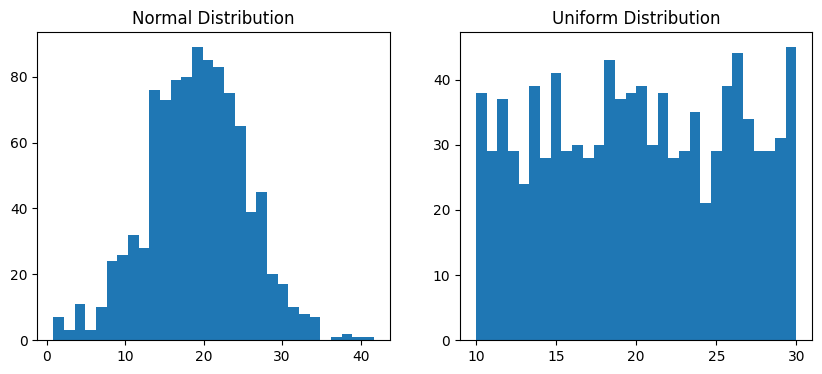

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data=np.array([10,12,15,18,20,22,25,30])

mean=np.mean(data)
variance=np.var(data)
std_dev=np.std(data)

print("Mean:",mean)
print("Variance:",variance)
print("Standard Deviation:",std_dev)

normal_data=np.random.normal(mean,std_dev,1000)
uniform_data=np.random.uniform(min(data),max(data),1000)

data2=np.array([8,11,14,17,21,23,26,28])

correlation=np.corrcoef(data,data2)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(normal_data,bins=30)
plt.title("Normal Distribution")

plt.subplot(1,2,2)
plt.hist(uniform_data,bins=30)
plt.title("Uniform Distribution")

plt.show()

**EXP 3 - Demonstrate Missing values Analysis, Fixing missing values and Outliers Analysis in a dataset**

original dataset:
      Age    Salary  Experience
0   22.0   25000.0         1.0
1   25.0   30000.0         3.0
2    NaN   28000.0         2.0
3   30.0       NaN         5.0
4   28.0   32000.0         NaN
5    NaN   31000.0        40.0
6   45.0  100000.0         4.0
7  120.0   29000.0         3.0
Missing Value Count:
 Age           2
Salary        1
Experience    1
dtype: int64

Dataset after handling missing values :
      Age    Salary  Experience
0   22.0   25000.0         1.0
1   25.0   30000.0         3.0
2   45.0   28000.0         2.0
3   30.0   30000.0         5.0
4   28.0   32000.0         3.0
5   45.0   31000.0        40.0
6   45.0  100000.0         4.0
7  120.0   29000.0         3.0

Outliers detected:
      Age  Salary  Experience
0  False   False       False
1  False   False       False
2  False   False       False
3  False   False       False
4  False   False       False
5  False   False        True
6  False    True       False
7   True   False       False

Dataset after h

/tmp/ipython-input-3076253081.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipython-input-3076253081.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

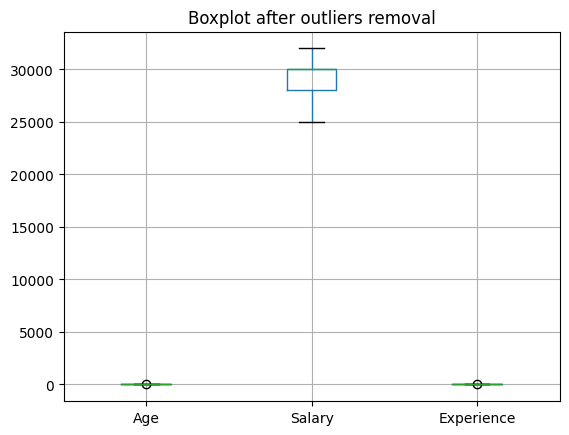

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data={
    'Age':[22,25,np.nan,30,28,np.nan,45,120],
    'Salary':[25000,30000,28000,np.nan,32000,31000,100000,29000],
    'Experience':[1,3,2,5,np.nan,40,4,3]
}

df=pd.DataFrame(data)

print("original dataset:\n",df)
print("Missing Value Count:\n",df.isnull().sum())

df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Salary'].fillna(df['Salary'].median(),inplace=True)
df['Experience'].fillna(df['Experience'].mode()[0],inplace=True)

print("\nDataset after handling missing values :\n",df)

Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1

outliers=((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR)))
print("\nOutliers detected:\n",outliers)

df_cleaned=df[~outliers.any(axis=1)]
print("\nDataset after handling outliers:\n",df_cleaned)

df_cleaned.boxplot()
plt.title("Boxplot after outliers removal")
plt.show()

**EXP 4 - Data visualization, histograms and multiple variable summaries**

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

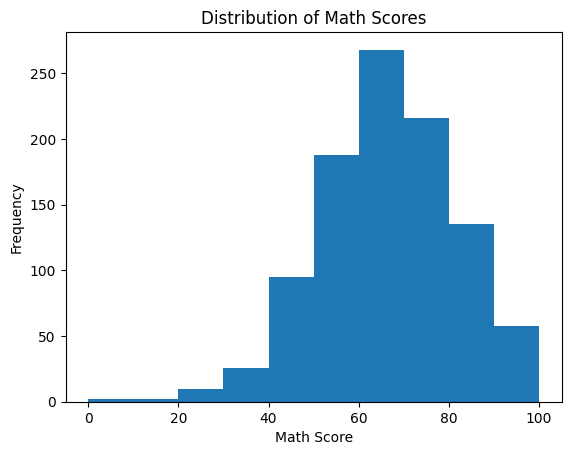

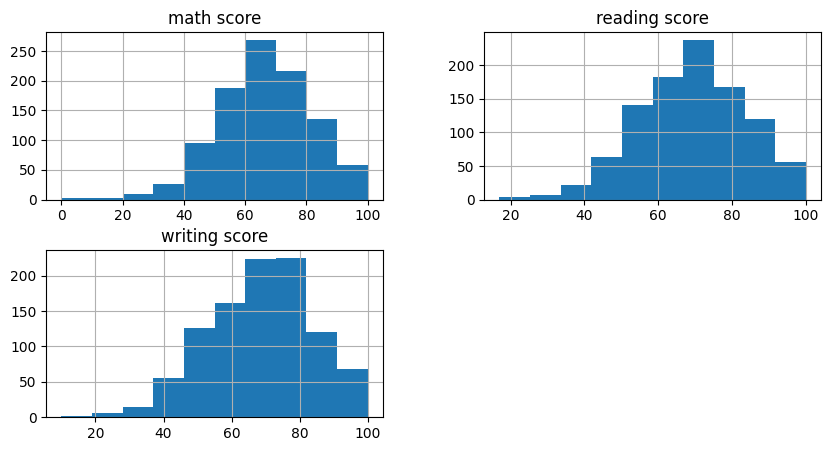

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


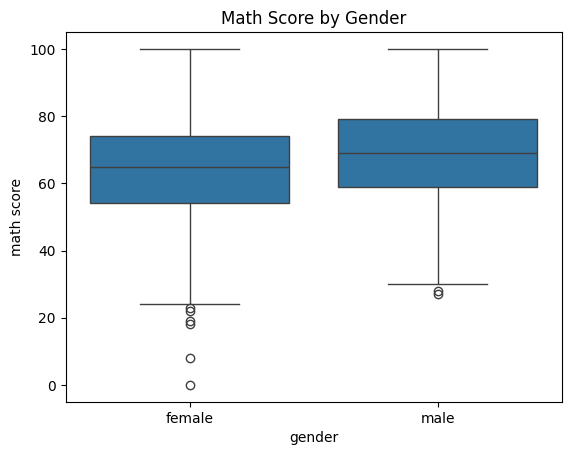

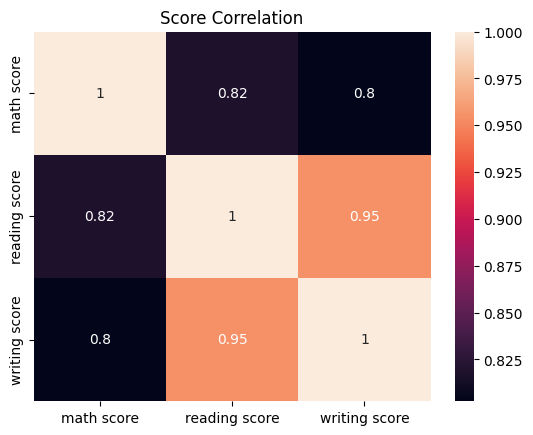

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/StudentsPerformance.csv")

print(df.head())
print(df.info())
print(df.describe())

print(df["math score"].describe())

plt.hist(df["math score"], bins=10)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

df[["math score","reading score","writing score"]].hist(bins=10, figsize=(10,5))
plt.show()

print(df.groupby("gender")[["math score","reading score","writing score"]].mean())

sns.boxplot(x="gender", y="math score", data=df)
plt.title("Math Score by Gender")
plt.show()

sns.heatmap(df[["math score","reading score","writing score"]].corr(), annot=True)
plt.title("Score Correlation")
plt.show()

**EXP 5 - Transformation, scaling, binning, fixing skewed values and sampling**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("StudentsPerformance.csv")

df["math_log"] = np.log1p(df["math score"])

scaler = MinMaxScaler()
df[["math_scaled","reading_scaled","writing_scaled"]] = scaler.fit_transform(
    df[["math score","reading score","writing score"]]
)

df["math_bin"] = pd.cut(df["math score"], bins=5, labels=["Very Low","Low","Medium","High","Very High"])

sample_df = df.sample(n=50)

print(df.head())
print(sample_df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  math_log  \
0                    none          72             72             74  4.290459   
1               completed          69             90             88  4.248495   
2                    none          90             95             93  4.510860   
3                    none          47             57             44  3.871201   
4                    none          76             78             75  4.343805   

   math_scaled  reading_scaled  writing_scaled   math_bin  
0         0.72        0.662651  

**EXP 6 - Apriori algorithm on transaction dataset to find association rules**

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

dataset = [
    ['Milk','Bread','Butter'],
    ['Bread','Butter'],
    ['Milk','Bread'],
    ['Milk','Butter'],
    ['Bread','Butter'],
    ['Milk','Bread','Butter'],
    ['Milk','Bread'],
    ['Butter']
]

te = TransactionEncoder()
te_array = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_array, columns=te.columns_)

frequent_items = apriori(df, min_support=0.3, use_colnames=True)

rules = association_rules(frequent_items, metric="confidence", min_threshold=0.6)

print(frequent_items)
print(rules)

   support         itemsets
0    0.750          (Bread)
1    0.750         (Butter)
2    0.625           (Milk)
3    0.500  (Bread, Butter)
4    0.500    (Bread, Milk)
5    0.375   (Milk, Butter)
  antecedents consequents  antecedent support  consequent support  support  \
0     (Bread)    (Butter)               0.750               0.750    0.500   
1    (Butter)     (Bread)               0.750               0.750    0.500   
2     (Bread)      (Milk)               0.750               0.625    0.500   
3      (Milk)     (Bread)               0.625               0.750    0.500   
4      (Milk)    (Butter)               0.625               0.750    0.375   

   confidence      lift  representativity  leverage  conviction  \
0    0.666667  0.888889               1.0  -0.06250       0.750   
1    0.666667  0.888889               1.0  -0.06250       0.750   
2    0.666667  1.066667               1.0   0.03125       1.125   
3    0.800000  1.066667               1.0   0.03125       1.250   


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**EXP 7 - Linear and Logistic regression using various domain datasets**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

df = pd.read_csv("StudentsPerformance.csv")

X = df[["reading score","writing score"]]
y = df["math score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(mean_squared_error(y_test,pred))

df["pass"] = (df["math score"] >= 50).astype(int)

X = df[["reading score","writing score"]]
y = df["pass"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

log = LogisticRegression(max_iter=500)
log.fit(X_train,y_train)

pred = log.predict(X_test)

print(accuracy_score(y_test,pred))

74.49667524165562
0.895


**EXP 8 - Decision Tree, Neural network and K-Nearest Neighbor**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("StudentsPerformance.csv")

df["performance"] = ((df["math score"] + df["reading score"] + df["writing score"]) / 3 > 70).astype(int)

X = df[["math score","reading score","writing score"]]
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
pred1 = dt.predict(X_test)
print(accuracy_score(y_test,pred1))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
pred2 = knn.predict(X_test)
print(accuracy_score(y_test,pred2))

nn = MLPClassifier(max_iter=1000)
nn.fit(X_train,y_train)
pred3 = nn.predict(X_test)
print(accuracy_score(y_test,pred3))

0.975
0.99
0.77


**EXP 9 - Temporal Mining Techniques**

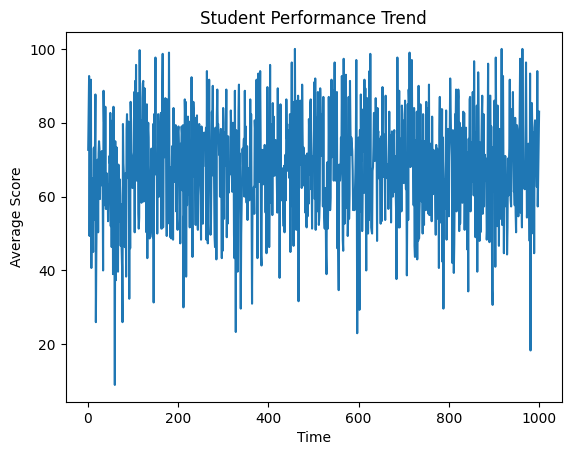

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")

df["time"] = range(1, len(df)+1)

df["average_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

df = df.sort_values("time")

plt.plot(df["time"], df["average_score"])
plt.title("Student Performance Trend")
plt.xlabel("Time")
plt.ylabel("Average Score")
plt.show()

**EXP 10 - Predictive analytics to analysis microarray data**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("StudentsPerformance.csv")

df["high_performance"] = ((df["math score"] + df["reading score"] + df["writing score"]) / 3 > 70).astype(int)

X = df[["math score","reading score","writing score"]]
y = df["high_performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(accuracy_score(y_test, pred))

0.985
